In [2]:
#importar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#ruta de los archivos y definición de los dataframes
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")


In [4]:
red = red.drop_duplicates()
white = white.drop_duplicates()

In [5]:
#agregar columna de tipo de vino y concatenar los dataframes
red["type"] = "red"
white["type"] = "white"
df = pd.concat([red, white], ignore_index=True)

In [6]:
#imprimir la media de calidad, alcohol y acidez volátil por tipo de vino
df.groupby("type")[["alcohol", "quality", "volatile acidity"]].mean()
df = pd.concat([red, white], ignore_index=True)

In [7]:
#correlaciones entre variables
df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.214752,0.330328,-0.104439,0.288918,-0.281590,-0.327471,0.478180,-0.271182,0.304844,-0.102573,-0.080092
volatile acidity,0.214752,1.000000,-0.384192,-0.163696,0.367626,-0.349039,-0.400716,0.308452,0.246687,0.227772,-0.065411,-0.265205
citric acid,0.330328,-0.384192,1.000000,0.146189,0.055199,0.130849,0.194835,0.094758,-0.344735,0.059183,-0.005496,0.097954
residual sugar,-0.104439,-0.163696,0.146189,1.000000,-0.123094,0.398717,0.487519,0.520930,-0.234522,-0.174717,-0.305242,-0.056830
chlorides,0.288918,0.367626,0.055199,-0.123094,1.000000,-0.186615,-0.269817,0.371867,0.025823,0.405051,-0.269601,-0.202137
free sulfur dioxide,-0.281590,-0.349039,0.130849,0.398717,-0.186615,1.000000,0.720488,0.006166,-0.141747,-0.198244,-0.170012,0.054002
total sulfur dioxide,-0.327471,-0.400716,0.194835,0.487519,-0.269817,0.720488,1.000000,0.006711,-0.222956,-0.275836,-0.249004,-0.050296
density,0.478180,0.308452,0.094758,0.520930,0.371867,0.006166,0.006711,1.000000,0.034273,0.282690,-0.667811,-0.326434
pH,-0.271182,0.246687,-0.344735,-0.234522,0.025823,-0.141747,-0.222956,0.034273,1.000000,0.168150,0.097314,0.039733
sulphates,0.304844,0.227772,0.059183,-0.174717,0.405051,-0.198244,-0.275836,0.282690,0.168150,1.000000,-0.017232,0.041884


In [8]:
df[['alcohol', 'quality']].corr()
#correlación entre alcohol y calidad

,alcohol,quality
alcohol,1.000000,0.469422
quality,0.469422,1.000000


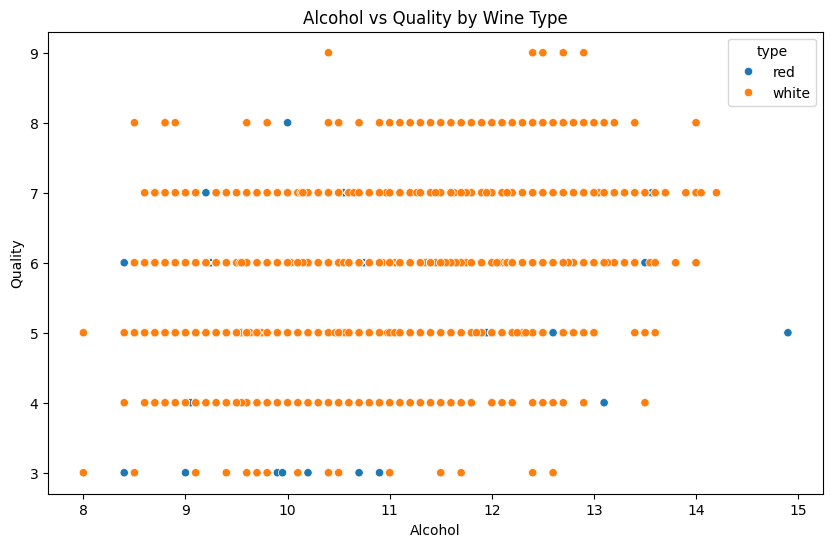

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="alcohol",
    y="quality",
    hue="type"
)

plt.title("Alcohol vs Quality by Wine Type")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

#los vinos tienen cierta relación con la cantidad de alcohol y la calidas

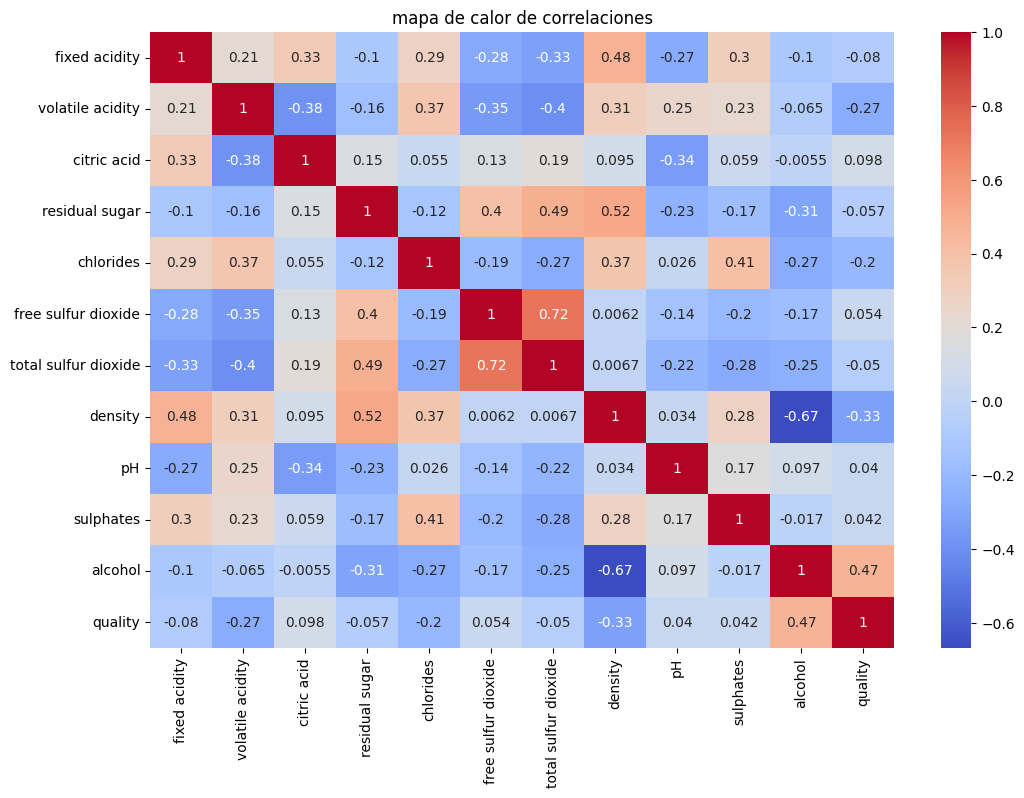

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("mapa de calor de correlaciones")
plt.show()

In [11]:
df[['residual sugar', 'density']].corr()

#una de las correlaciones más fuertes es entre el azúcar residual y la densidad, lo que también podemos ver en el mapa

,residual sugar,density
residual sugar,1.00000,0.52093
density,0.52093,1.00000


In [12]:
print(df.corr(numeric_only=True)["quality"].sort_values(ascending=False))
#esto nos muestra las variables que más influyen en la calidad del vino

quality                 1.000000
alcohol                 0.469422
citric acid             0.097954
free sulfur dioxide     0.054002
sulphates               0.041884
pH                      0.039733
total sulfur dioxide   -0.050296
residual sugar         -0.056830
fixed acidity          -0.080092
chlorides              -0.202137
volatile acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64


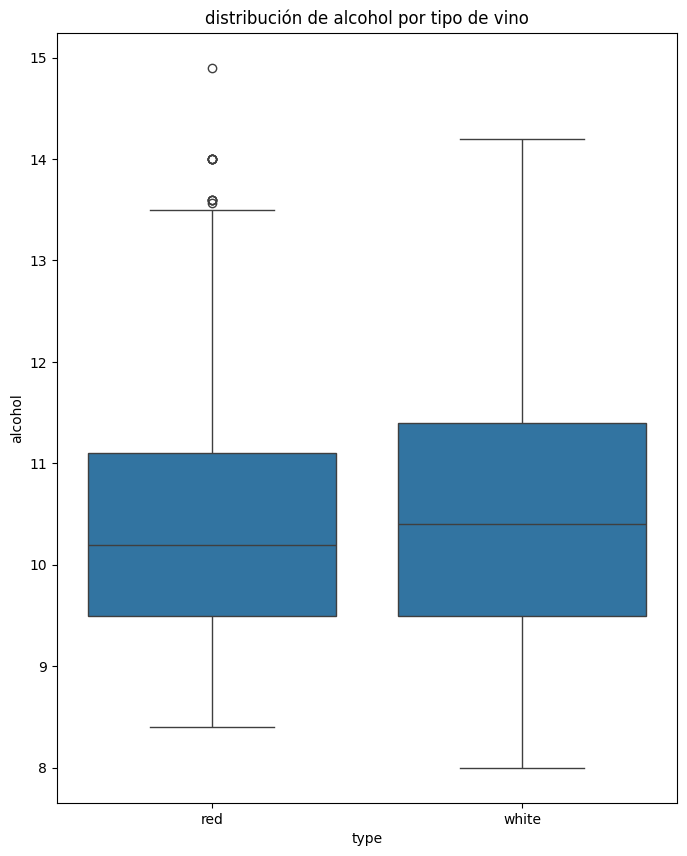

In [13]:
plt.figure(figsize=(8,10))

sns.boxplot(data=df, x="type", y="alcohol")

plt.title("distribución de alcohol por tipo de vino")
plt.show()
#los vinos blancos tienen una mayor cantidad de alcohol en promedio que los rojos, lo que también puede influir en la calidad

<Axes: xlabel='quality', ylabel='count'>

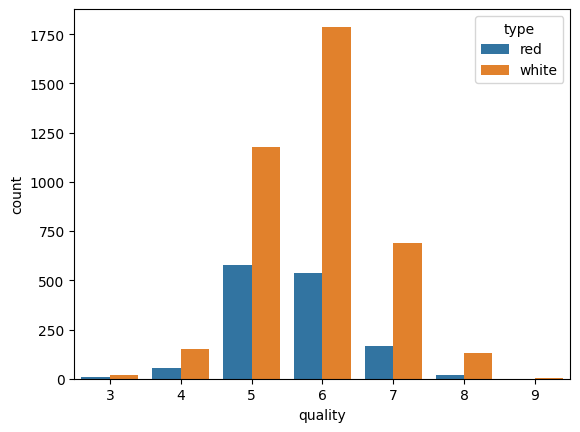

In [14]:
sns.countplot(x="quality", hue="type", data=df)
#hay mucho más vinos blancos que rojos, lo que puede influir en la distribución de calidad

CONCLUSIONES:

La muestra está desbalanceada, hay mucho menos vino rojo lo que puede influir en los resultados

Los vinos blancos tienen una mayor cantidad de alcohol en promedio que los rojos, lo que también puede influir en la calidad

Una de las correlaciones más fuertes es entre el azúcar residual y la densidad

Las variables que más influyen en la calidad son: alcohol, ácido cítrico y libre de dióxido de sulfuro